# OEIS A112509 — Extended Results ($n = 1$ to $70$)

This notebook presents pre-computed results for A112509 values up to $n=70$, generated using an optimized block-based search algorithm.

**Prerequisites:** See `A112509_Introduction.ipynb` for the problem definition and brute-force approach for $n \leq 20$.

**Algorithm:** For $n > 20$, results are computed by `src/compute_cached_clean.py` using:
- Block-based search with 1-blocks and 0-separators
- Pre-learned structural bounds from config/learned_bounds.json
- Optimized bit operations for substring counting
- Optional min/max 1s density constraints
- Parallel processing with multiprocessing

Results are cached in `data/cached_results.json`.

**For algorithm analysis:** See `A112509_Algorithm_Analysis.ipynb` for detailed structural analysis and constraint tuning.

In [ ]:
import sys, os

# Set project root relative to this notebook (works for any user)
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
sys.path.insert(0, PROJECT_ROOT)

import json
import re
from IPython.display import display, HTML
from data.reference.known_values import KNOWN_VALUES

# Helper functions
def run_lengths(s, ch):
    """Return list of lengths of maximal runs of character ch in s."""
    return [len(m.group()) for m in re.finditer(f'{ch}+', s)]

def fmt_range(vals):
    """Format a set/list of ints as 'min-max' or just 'val' if all same."""
    lo, hi = min(vals), max(vals)
    return str(lo) if lo == hi else f"{lo}–{hi}"

## Load Cached Results

In [ ]:
cache_path = os.path.join(PROJECT_ROOT, "data", "cached_results.json")
with open(cache_path, "r") as f:
    cache = json.load(f)

print(f"✓ Loaded {len(cache)} cached values")
print(f"✓ Range: n={min(int(k) for k in cache.keys())} to n={max(int(k) for k in cache.keys())}")

✓ Loaded 150 cached values
✓ Range: n=1 to n=150


## Sequence Values and Optimal Strings (All Values)

In [3]:
# Build complete results list for all n values
all_results = []
for key in sorted(cache.keys(), key=int):
    n = int(key)
    entry = cache[key]
    known = KNOWN_VALUES[n - 1] if n <= len(KNOWN_VALUES) else None
    match = entry["a(n)"] == known if known is not None else None
    all_results.append({
        "n": n,
        "a(n)": entry["a(n)"],
        "known": known,
        "match": match,
        "num_optimal": entry["num_optimal"],
        "optimal_strings": entry["optimal_strings"],
        "K_common": entry.get("K_common"),
        "common_seps": entry.get("common_seps"),
    })

# Function to generate table rows for a range of n
def generate_result_rows(results, start_n, end_n):
    rows = ""
    for r in results:
        n = r["n"]
        if n < start_n or n > end_n:
            continue
        check = "✓" if r["match"] else ("✗" if r["match"] is False else "–")
        strs_html = ", &nbsp;".join(f"<code>{s}</code>" for s in r["optimal_strings"])
        rows += (
            f"<tr>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:right'>{r['a(n)']}</td>"
            f"<td style='text-align:center'>{check}</td>"
            f"<td style='text-align:right'>{r['num_optimal']}</td>"
            f"<td style='text-align:left; max-width:800px; word-wrap:break-word'>{strs_html}</td>"
            f"</tr>\n"
        )
    return rows

# Generate tables for each group of 10
max_n = max(r["n"] for r in all_results)
groups = []
for start in range(1, max_n + 1, 10):
    end = min(start + 9, max_n)
    groups.append((start, end))

# Build HTML with tabs/buttons
buttons_html = ""
tables_html = ""

for i, (start, end) in enumerate(groups):
    group_id = f"results_group_{start}_{end}"
    active = "active-res" if i == 0 else ""
    display_style = "block" if i == 0 else "none"
    
    buttons_html += f'<button class="res-btn {active}" onclick="showResultsGroup(\'{group_id}\')">n={start}–{end}</button>\n'
    
    rows = generate_result_rows(all_results, start, end)
    tables_html += f"""
<div id="{group_id}" class="results-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:right;">n</th>
  <th style="padding:4px 10px; text-align:right;">a(n)</th>
  <th style="padding:4px 10px; text-align:center;">✓</th>
  <th style="padding:4px 10px; text-align:right;"># optimal</th>
  <th style="padding:4px 10px; text-align:left;">all optimal strings</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html = f"""
<style>
.res-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.res-btn:hover {{
    background-color: #ddd;
}}
.res-btn.active-res {{
    background-color: #2196F3;
    color: white;
    border-bottom: 2px solid #2196F3;
}}
.results-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>

<script>
function showResultsGroup(groupId) {{
    var tables = document.getElementsByClassName('results-table');
    for (var i = 0; i < tables.length; i++) {{
        tables[i].style.display = 'none';
    }}
    var buttons = document.getElementsByClassName('res-btn');
    for (var i = 0; i < buttons.length; i++) {{
        buttons[i].classList.remove('active-res');
    }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-res');
}}
</script>

<h3>Sequence Values and Optimal Strings</h3>
<div style="margin-bottom: 10px;">
{buttons_html}
</div>
{tables_html}
"""

display(HTML(html))


n,a(n),✓,# optimal,all optimal strings
1,1,✓,2,"0, 1"
2,3,✓,1,10
3,5,✓,1,110
4,7,✓,3,"1100, 1101, 1110"
5,10,✓,2,"11100, 11101"
6,13,✓,6,"111000, 111001, 111010, 111011, 111100, 111101"
7,17,✓,5,"1110100, 1111000, 1111001, 1111010, 1111011"
8,22,✓,1,11110100
9,27,✓,4,"111101000, 111101001, 111101100, 111110100"
10,33,✓,5,"1111011000, 1111011001, 1111101000, 1111101001, 1111101100"


## Structural Analysis (By Groups of 10)

In [4]:

# ── TABLE 1: n = 1 to 100 ──────────────────────────────────────────────

def generate_structural_rows(results, start_n, end_n):
    rows = ""
    for r in results:
        n = r["n"]
        if n < start_n or n > end_n:
            continue

        strs = r["optimal_strings"]
        k_common_str = str(r["K_common"]) if r.get("K_common") is not None else "–"
        common_seps = r.get("common_seps")
        seps_str = str(common_seps) if common_seps is not None else "–"

        leading_1s = [len(s) - len(s.lstrip("1")) for s in strs]

        second_1blocks = []
        for s in strs:
            blocks_1 = run_lengths(s, '1')
            if len(blocks_1) >= 2:
                second_1blocks.append(blocks_1[1])
        second_1block_str = fmt_range(second_1blocks) if second_1blocks else "–"

        num_1blocks = [len(run_lengths(s, '1')) for s in strs]
        num_0blocks = [len(run_lengths(s, '0')) for s in strs]
        num_1blocks_str = fmt_range(num_1blocks) if num_1blocks else "–"
        num_0blocks_str = fmt_range(num_0blocks) if num_0blocks else "–"

        total_1s = [s.count('1') for s in strs]
        total_0s = [s.count('0') for s in strs]
        total_1s_str = fmt_range(total_1s)
        total_0s_str = fmt_range(total_0s)

        strs_with_0 = [s for s in strs if '0' in s]
        if strs_with_0:
            longest_0 = fmt_range([max(run_lengths(s, '0')) for s in strs_with_0])
        else:
            longest_0 = "–"

        densities = [s.count("1") / n for s in strs]
        min_density = min(densities)
        max_density = max(densities)
        density_str = f"{min_density:.2f}" if min_density == max_density else f"{min_density:.2f}–{max_density:.2f}"

        rows += (
            f"<tr>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:center'>{num_1blocks_str}</td>"
            f"<td style='text-align:center'>{num_0blocks_str}</td>"
            f"<td style='text-align:center'>{total_1s_str}</td>"
            f"<td style='text-align:center'>{total_0s_str}</td>"
            f"<td style='text-align:center'>{fmt_range(leading_1s)}</td>"
            f"<td style='text-align:center'>{second_1block_str}</td>"
            f"<td style='text-align:center'>{longest_0}</td>"
            f"<td style='text-align:right'>{density_str}</td>"
            f"<td style='text-align:center'>{k_common_str}</td>"
            f"<td style='text-align:left; font-size:11px; color:#555;'>{seps_str}</td>"
            f"<td style='text-align:right'>{r['num_optimal']}</td>"
            f"</tr>\n"
        )
    return rows

results_1_100 = [r for r in all_results if 1 <= r["n"] <= 100]
results_101_plus = [r for r in all_results if r["n"] > 100]

# Build tabs for n=1..100
groups_1_100 = []
for start in range(1, 101, 10):
    end = min(start + 9, 100)
    if any(r["n"] >= start and r["n"] <= end for r in results_1_100):
        groups_1_100.append((start, end))

buttons_html_1 = ""
tables_html_1 = ""

for i, (start, end) in enumerate(groups_1_100):
    group_id = f"struct1_group_{start}_{end}"
    active = "active-struct1" if i == 0 else ""
    display_style = "block" if i == 0 else "none"

    buttons_html_1 += f'<button class="struct1-btn {active}" onclick="showStruct1Group(\'{group_id}\')">n={start}–{end}</button>\n'

    rows = generate_structural_rows(results_1_100, start, end)
    tables_html_1 += f"""
<div id="{group_id}" class="struct1-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 8px; text-align:right;">n</th>
  <th style="padding:4px 8px; text-align:center;"># 1-blocks</th>
  <th style="padding:4px 8px; text-align:center;"># 0-blocks</th>
  <th style="padding:4px 8px; text-align:center;">total 1s</th>
  <th style="padding:4px 8px; text-align:center;">total 0s</th>
  <th style="padding:4px 8px; text-align:center;">leading 1s</th>
  <th style="padding:4px 8px; text-align:center;">2nd 1-block</th>
  <th style="padding:4px 8px; text-align:center;">max 0-run</th>
  <th style="padding:4px 8px; text-align:right;">1-density</th>
  <th style="padding:4px 8px; text-align:center;">K_common</th>
  <th style="padding:4px 8px; text-align:left;">common seps</th>
  <th style="padding:4px 8px; text-align:right;"># opt</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html1 = f"""
<style>
.struct1-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.struct1-btn:hover {{ background-color: #ddd; }}
.struct1-btn.active-struct1 {{
    background-color: #4CAF50;
    color: white;
    border-bottom: 2px solid #4CAF50;
}}
.struct1-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showStruct1Group(groupId) {{
    var tables = document.getElementsByClassName('struct1-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('struct1-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-struct1'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-struct1');
}}
</script>
<h3>Structural Analysis: n = 1–100</h3>
<div style="margin-bottom: 10px;">{buttons_html_1}</div>
{tables_html_1}
"""
display(HTML(html1))

# ── TABLE 2: n = 101+ ──────────────────────────────────────────────────

def generate_structural_rows_extended(results, start_n, end_n):
    rows = ""
    for r in results:
        n = r["n"]
        if n < start_n or n > end_n:
            continue

        strs = r["optimal_strings"]
        k_common_str = str(r["K_common"]) if r.get("K_common") is not None else "–"
        common_seps = r.get("common_seps")
        seps_str = str(common_seps) if common_seps is not None else "–"

        leading_1s = [len(s) - len(s.lstrip("1")) for s in strs]

        def nth_1block(strs, idx):
            vals = []
            for s in strs:
                blocks_1 = run_lengths(s, '1')
                if len(blocks_1) > idx:
                    vals.append(blocks_1[idx])
            return fmt_range(vals) if vals else "–"

        second_1block_str = nth_1block(strs, 1)
        third_1block_str  = nth_1block(strs, 2)
        fifth_1block_str  = nth_1block(strs, 4)

        num_1blocks = [len(run_lengths(s, '1')) for s in strs]
        num_0blocks = [len(run_lengths(s, '0')) for s in strs]
        num_1blocks_str = fmt_range(num_1blocks) if num_1blocks else "–"
        num_0blocks_str = fmt_range(num_0blocks) if num_0blocks else "–"

        total_1s = [s.count('1') for s in strs]
        total_0s = [s.count('0') for s in strs]
        total_1s_str = fmt_range(total_1s)
        total_0s_str = fmt_range(total_0s)

        strs_with_0 = [s for s in strs if '0' in s]
        longest_0 = fmt_range([max(run_lengths(s, '0')) for s in strs_with_0]) if strs_with_0 else "–"

        densities = [s.count("1") / n for s in strs]
        min_d, max_d = min(densities), max(densities)
        density_str = f"{min_d:.4f}" if min_d == max_d else f"{min_d:.4f}–{max_d:.4f}"

        rows += (
            f"<tr>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:center'>{num_1blocks_str}</td>"
            f"<td style='text-align:center'>{num_0blocks_str}</td>"
            f"<td style='text-align:center'>{total_1s_str}</td>"
            f"<td style='text-align:center'>{total_0s_str}</td>"
            f"<td style='text-align:center'>{fmt_range(leading_1s)}</td>"
            f"<td style='text-align:center'>{second_1block_str}</td>"
            f"<td style='text-align:center'>{third_1block_str}</td>"
            f"<td style='text-align:center'>{fifth_1block_str}</td>"
            f"<td style='text-align:center'>{longest_0}</td>"
            f"<td style='text-align:right'>{density_str}</td>"
            f"<td style='text-align:center'>{k_common_str}</td>"
            f"<td style='text-align:left; font-size:11px; color:#555;'>{seps_str}</td>"
            f"<td style='text-align:right'>{r['num_optimal']}</td>"
            f"</tr>\n"
        )
    return rows

if results_101_plus:
    max_n_ext = max(r["n"] for r in results_101_plus)
    groups_101 = []
    for start in range(101, max_n_ext + 1, 10):
        end = min(start + 9, max_n_ext)
        if any(r["n"] >= start and r["n"] <= end for r in results_101_plus):
            groups_101.append((start, end))

    buttons_html_2 = ""
    tables_html_2 = ""

    for i, (start, end) in enumerate(groups_101):
        group_id = f"struct2_group_{start}_{end}"
        active = "active-struct2" if i == 0 else ""
        display_style = "block" if i == 0 else "none"

        buttons_html_2 += f'<button class="struct2-btn {active}" onclick="showStruct2Group(\'{group_id}\')">n={start}–{end}</button>\n'

        rows = generate_structural_rows_extended(results_101_plus, start, end)
        tables_html_2 += f"""
<div id="{group_id}" class="struct2-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 8px; text-align:right;">n</th>
  <th style="padding:4px 8px; text-align:center;"># 1-blk</th>
  <th style="padding:4px 8px; text-align:center;"># 0-blk</th>
  <th style="padding:4px 8px; text-align:center;">total 1s</th>
  <th style="padding:4px 8px; text-align:center;">total 0s</th>
  <th style="padding:4px 8px; text-align:center;">1st 1-blk</th>
  <th style="padding:4px 8px; text-align:center;">2nd 1-blk</th>
  <th style="padding:4px 8px; text-align:center;">3rd 1-blk</th>
  <th style="padding:4px 8px; text-align:center;">5th 1-blk</th>
  <th style="padding:4px 8px; text-align:center;">max 0-run</th>
  <th style="padding:4px 8px; text-align:right;">1-density</th>
  <th style="padding:4px 8px; text-align:center;">K_common</th>
  <th style="padding:4px 8px; text-align:left;">common seps</th>
  <th style="padding:4px 8px; text-align:right;"># opt</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

    html2 = f"""
<style>
.struct2-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.struct2-btn:hover {{ background-color: #ddd; }}
.struct2-btn.active-struct2 {{
    background-color: #9C27B0;
    color: white;
    border-bottom: 2px solid #9C27B0;
}}
.struct2-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showStruct2Group(groupId) {{
    var tables = document.getElementsByClassName('struct2-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('struct2-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-struct2'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-struct2');
}}
</script>
<h3>Structural Analysis: n ≥ 101 (Extended)</h3>
<div style="margin-bottom: 10px;">{buttons_html_2}</div>
{tables_html_2}
"""
    display(HTML(html2))
else:
    print("No results for n > 100 yet.")


n,# 1-blocks,# 0-blocks,total 1s,total 0s,leading 1s,2nd 1-block,max 0-run,1-density,K_common,common seps,# opt
1,0–1,0–1,0–1,0–1,0–1,–,1,0.00–1.00,0,[],2
2,1,1,1,1,1,–,1,0.50,1,[1],1
3,1,1,2,1,2,–,1,0.67,1,[1],1
4,1–2,1,2–3,1–2,2–3,1,1–2,0.50–0.75,0,[],3
5,1–2,1,3–4,1–2,3,1,1–2,0.60–0.80,0,[],2
6,1–2,1–2,3–5,1–3,3–4,1–2,1–3,0.50–0.83,0,[],6
7,1–2,1–2,4–6,1–3,3–4,1–2,1–3,0.57–0.86,0,[],5
8,2,2,5,3,4,1,2,0.62,2,"[1, 2]",1
9,2–3,2,5–6,3–4,4–5,1–2,2–3,0.56–0.67,1,[1],4
10,2–3,2,6–7,3–4,4–5,1–2,2–3,0.60–0.70,1,[1],5


n,# 1-blk,# 0-blk,total 1s,total 0s,1st 1-blk,2nd 1-blk,3rd 1-blk,5th 1-blk,max 0-run,1-density,K_common,common seps,# opt
101,11–14,11–13,82–86,15–19,19–20,16–17,13–14,9–10,3–7,0.8119–0.8515,8,"[1, 2, 1, 1, 1, 1, 1, 1]",236
102,11–14,11–13,83–86,16–19,19–20,16–17,13–14,9–10,3–6,0.8137–0.8431,8,"[1, 2, 1, 1, 1, 1, 1, 1]",144
103,12–14,12–13,84–86,17–19,19–20,16–17,13–14,9–10,3–5,0.8155–0.8350,8,"[1, 2, 1, 1, 1, 1, 1, 1]",101
104,12–14,12–13,85–87,17–19,19–20,16–17,13–14,9–10,3–5,0.8173–0.8365,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",44
105,12–14,12–13,86–88,17–19,20,17,14,10,3–5,0.8190–0.8381,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",8
106,12–14,12–14,86–89,17–20,20–21,17–18,14–15,10–11,3–6,0.8113–0.8396,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",60
107,12–14,12–14,87–90,17–20,20–21,17–18,14–15,10–11,3–6,0.8131–0.8411,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",190
108,12–14,12–14,88–91,17–20,20–21,17–18,14–15,10–11,3–6,0.8148–0.8426,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",331
109,12–14,12–14,89–92,17–20,20–21,17–18,14–15,10–11,3–6,0.8165–0.8440,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",345
110,12–14,12–14,90–93,17–20,20–21,17–18,14–15,10–11,3–6,0.8182–0.8455,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",218


## K_common vs n

For each $n$, **K_common** is the length of the longest 0-separator prefix that is identical across 100% of optimal solutions — a measure of how much structural rigidity is shared at the start of optimal strings.


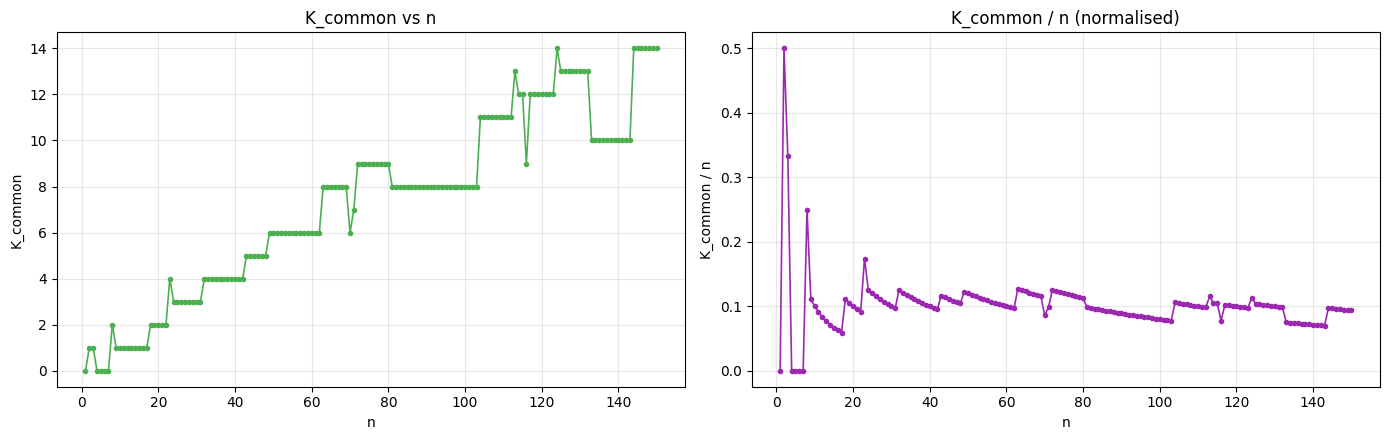

n range       : 1–150
K_common range: 0–14
Mean K_common : 7.32


In [5]:
import matplotlib.pyplot as plt

n_kc = [r["n"] for r in all_results if r.get("K_common") is not None]
k_vals = [r["K_common"] for r in all_results if r.get("K_common") is not None]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Chart 1: K_common vs n (all n)
axes[0].plot(n_kc, k_vals, marker="o", linewidth=1.2, markersize=3, color="#4CAF50")
axes[0].set_title("K_common vs n")
axes[0].set_xlabel("n")
axes[0].set_ylabel("K_common")
axes[0].grid(alpha=0.3)

# Chart 2: K_common / n (normalised fraction of separators that are shared)
kc_ratio = [k / n for k, n in zip(k_vals, n_kc)]
axes[1].plot(n_kc, kc_ratio, marker="o", linewidth=1.2, markersize=3, color="#9C27B0")
axes[1].set_title("K_common / n (normalised)")
axes[1].set_xlabel("n")
axes[1].set_ylabel("K_common / n")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"n range       : {n_kc[0]}–{n_kc[-1]}")
print(f"K_common range: {min(k_vals)}–{max(k_vals)}")
print(f"Mean K_common : {sum(k_vals)/len(k_vals):.2f}")


## Hamming Distance Between Optimal Solutions

For each $n$, this table shows the **minimum**, **maximum**, and **mean** pairwise Hamming distance between all known optimal bit-strings. When there is only one optimal solution the distances are 0 by convention.


In [13]:
from itertools import combinations
from IPython.display import display, HTML

# Compute Hamming distances from all_results (defined in earlier cell)
def hamming_dist(s1, s2):
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

hamming = {}
for r in all_results:
    n = r["n"]
    strs = r["optimal_strings"]
    num = len(strs)
    if num <= 1:
        hamming[str(n)] = {"num_solutions": num, "min": 0, "max": 0, "mean": 0.0}
    else:
        dists = [hamming_dist(a, b) for a, b in combinations(strs, 2)]
        hamming[str(n)] = {
            "num_solutions": num,
            "min": min(dists),
            "max": max(dists),
            "mean": sum(dists) / len(dists),
        }

# Build tabbed groups of 10
max_n_h = max(int(k) for k in hamming)
groups_h = []
for start in range(1, max_n_h + 1, 10):
    end = min(start + 9, max_n_h)
    if any(start <= int(k) <= end for k in hamming):
        groups_h.append((start, end))

buttons_html_h = ""
tables_html_h = ""

for i, (start, end) in enumerate(groups_h):
    group_id = f"hamming_group_{start}_{end}"
    active = "active-ham" if i == 0 else ""
    display_style = "block" if i == 0 else "none"

    buttons_html_h += f'<button class="ham-btn {active}" onclick="showHammingGroup(\'{group_id}\')">n={start}–{end}</button>\n'

    rows = ""
    for n in range(start, end + 1):
        k = str(n)
        if k not in hamming:
            continue
        h = hamming[k]
        rows += (
            f"<tr>"
            f"<td style='text-align:right; padding:3px 10px;'>{n}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{h['num_solutions']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{h['min']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{h['max']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{h['mean']:.2f}</td>"
            f"</tr>\n"
        )

    tables_html_h += f"""
<div id="{group_id}" class="hamming-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:right;">n</th>
  <th style="padding:4px 10px; text-align:right;"># Solutions</th>
  <th style="padding:4px 10px; text-align:right;">Min</th>
  <th style="padding:4px 10px; text-align:right;">Max</th>
  <th style="padding:4px 10px; text-align:right;">Mean</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html_h = f"""
<style>
.ham-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.ham-btn:hover {{ background-color: #ddd; }}
.ham-btn.active-ham {{
    background-color: #FF9800;
    color: white;
    border-bottom: 2px solid #FF9800;
}}
.hamming-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showHammingGroup(groupId) {{
    var tables = document.getElementsByClassName('hamming-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('ham-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-ham'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-ham');
}}
</script>
<h3>Hamming Distance Between Optimal Solutions</h3>
<p style="font-size:12px; color:#555;">
  Pairwise Hamming distance over all C(k,2) pairs of optimal bit-strings.
  Single-solution cases: min = max = mean = 0 by convention.
</p>
<div style="margin-bottom: 10px;">{buttons_html_h}</div>
{tables_html_h}
"""
display(HTML(html_h))

n,# Solutions,Min,Max,Mean
1,2,1,1,1.00
2,1,0,0,0.00
3,1,0,0,0.00
4,3,1,2,1.33
5,2,1,1,1.00
6,6,1,3,1.67
7,5,1,4,2.00
8,1,0,0,0.00
9,4,1,4,2.17
10,5,1,4,2.20


## Growth Analysis

In [7]:
def generate_growth_rows(results, start_n, end_n):
    rows = ""
    for i, r in enumerate(results):
        n = r["n"]
        if n < start_n or n > end_n:
            continue
        an = r["a(n)"]
        num_opt = r["num_optimal"]

        if n <= len(KNOWN_VALUES):
            value_match = "✓" if an == KNOWN_VALUES[n-1] else "✗"
        else:
            value_match = "–"

        try:
            from data.reference.known_values import A156025_VALUES
            if n <= len(A156025_VALUES):
                count_match = "✓" if num_opt == A156025_VALUES[n-1] else "✗"
            else:
                count_match = "–"
        except ImportError:
            count_match = "–"

        delta = an - results[i-1]["a(n)"] if i > 0 else None
        ddelta = None
        if i >= 2:
            d1 = results[i]["a(n)"] - results[i-1]["a(n)"]
            d0 = results[i-1]["a(n)"] - results[i-2]["a(n)"]
            ddelta = d1 - d0

        delta_str = str(delta) if delta is not None else "–"
        ddelta_str = str(ddelta) if ddelta is not None else "–"

        rows += (
            f"<tr>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:right'>{an}</td>"
            f"<td style='text-align:center'>{value_match}</td>"
            f"<td style='text-align:right'>{num_opt}</td>"
            f"<td style='text-align:center'>{count_match}</td>"
            f"<td style='text-align:right'>{delta_str}</td>"
            f"<td style='text-align:right'>{ddelta_str}</td>"
            f"<td style='text-align:right'>{an/n:.2f}</td>"
            f"<td style='text-align:right'>{an/n**2:.4f}</td>"
            f"</tr>\n"
        )
    return rows

max_n_g = max(r["n"] for r in all_results)
groups_g = []
for start in range(1, max_n_g + 1, 10):
    end = min(start + 9, max_n_g)
    if any(r["n"] >= start and r["n"] <= end for r in all_results):
        groups_g.append((start, end))

buttons_html_g = ""
tables_html_g = ""

for i, (start, end) in enumerate(groups_g):
    group_id = f"growth_group_{start}_{end}"
    active = "active-grow" if i == 0 else ""
    display_style = "block" if i == 0 else "none"

    buttons_html_g += f'<button class="grow-btn {active}" onclick="showGrowthGroup(\'{group_id}\')">n={start}–{end}</button>\n'

    rows = generate_growth_rows(all_results, start, end)
    tables_html_g += f"""
<div id="{group_id}" class="growth-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:right;">n</th>
  <th style="padding:4px 10px; text-align:right;">a(n)</th>
  <th style="padding:4px 10px; text-align:center;">a(n) ✓</th>
  <th style="padding:4px 10px; text-align:right;"># opt</th>
  <th style="padding:4px 10px; text-align:center;"># opt ✓</th>
  <th style="padding:4px 10px; text-align:right;">Δa</th>
  <th style="padding:4px 10px; text-align:right;">ΔΔa</th>
  <th style="padding:4px 10px; text-align:right;">a(n)/n</th>
  <th style="padding:4px 10px; text-align:right;">a(n)/n²</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html = f"""
<style>
.grow-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.grow-btn:hover {{ background-color: #ddd; }}
.grow-btn.active-grow {{
    background-color: #E91E63;
    color: white;
    border-bottom: 2px solid #E91E63;
}}
.growth-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showGrowthGroup(groupId) {{
    var tables = document.getElementsByClassName('growth-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('grow-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-grow'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-grow');
}}
</script>
<h3>Growth Analysis (All Values)</h3>
<div style="margin-bottom: 10px;">{buttons_html_g}</div>
{tables_html_g}
"""

display(HTML(html))

n,a(n),a(n) ✓,# opt,# opt ✓,Δa,ΔΔa,a(n)/n,a(n)/n²
1,1,✓,2,✓,–,–,1.00,1.0000
2,3,✓,1,✓,2,–,1.50,0.7500
3,5,✓,1,✓,2,0,1.67,0.5556
4,7,✓,3,✓,2,0,1.75,0.4375
5,10,✓,2,✓,3,1,2.00,0.4000
6,13,✓,6,✓,3,0,2.17,0.3611
7,17,✓,5,✓,4,1,2.43,0.3469
8,22,✓,1,✓,5,1,2.75,0.3438
9,27,✓,4,✓,5,0,3.00,0.3333
10,33,✓,5,✓,6,1,3.30,0.3300


## Plots: Normalized Growth and Number of Optimal Solutions

The first chart shows $a(n)/n^2$ across all available $n$.

For the number of optimal solutions, a log-scale y-axis is used to handle the wide range (from 1 to over 200) while keeping smaller values visible.

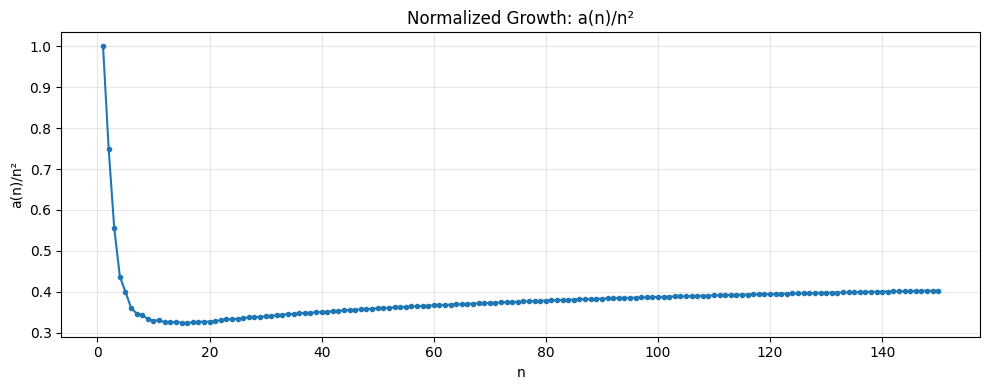

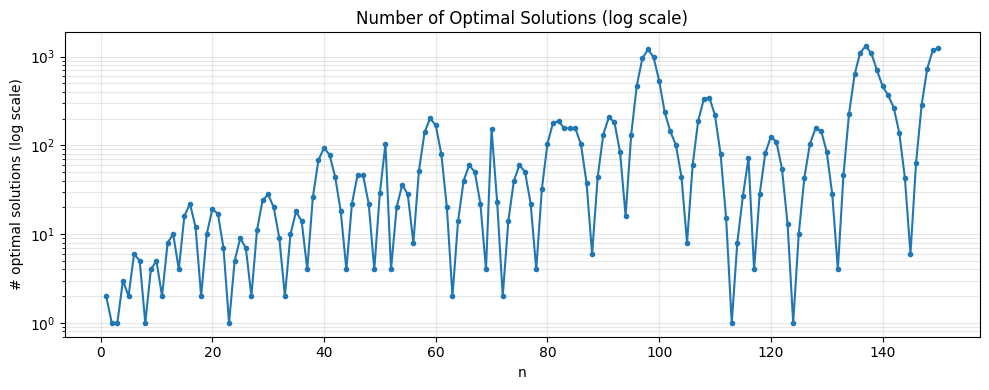

In [8]:
import matplotlib.pyplot as plt

n_vals = [r["n"] for r in all_results]
a_vals = [r["a(n)"] for r in all_results]
num_opt_vals = [r["num_optimal"] for r in all_results]

ratio_vals = [a / (n**2) for a, n in zip(a_vals, n_vals)]

# Chart 1: a(n)/n^2
plt.figure(figsize=(10, 4))
plt.plot(n_vals, ratio_vals, marker="o", linewidth=1.5, markersize=3)
plt.title("Normalized Growth: a(n)/n²")
plt.xlabel("n")
plt.ylabel("a(n)/n²")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Chart 2: Number of optimal solutions (log scale)
plt.figure(figsize=(10, 4))
plt.plot(n_vals, num_opt_vals, marker="o", linewidth=1.5, markersize=3)
plt.yscale("log")
plt.title("Number of Optimal Solutions (log scale)")
plt.xlabel("n")
plt.ylabel("# optimal solutions (log scale)")
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Additional Chart: Normalized Growth for $n \geq 20$ (with Added Exact Large-$n$ Values)

This chart reduces small-$n$ noise by plotting only $n \geq 20$ and including the additional exact values you provided:

- $a(150)=9070$
- $a(200)=16535$
- $a(300)=38393$

To match the known data exactly, we use a shape-preserving cubic interpolant (PCHIP) on observed points.

For asymptotic behavior, a separate extrapolation chart fits a constrained log-base-2 tail model:

$$
\frac{a(n)}{n^2} \approx L - \frac{c}{(\log_2 n)^{\alpha}}, \quad L < 0.5.
$$

We report $L$ from multiple tail cutoffs to provide a robust asymptotic estimate range.

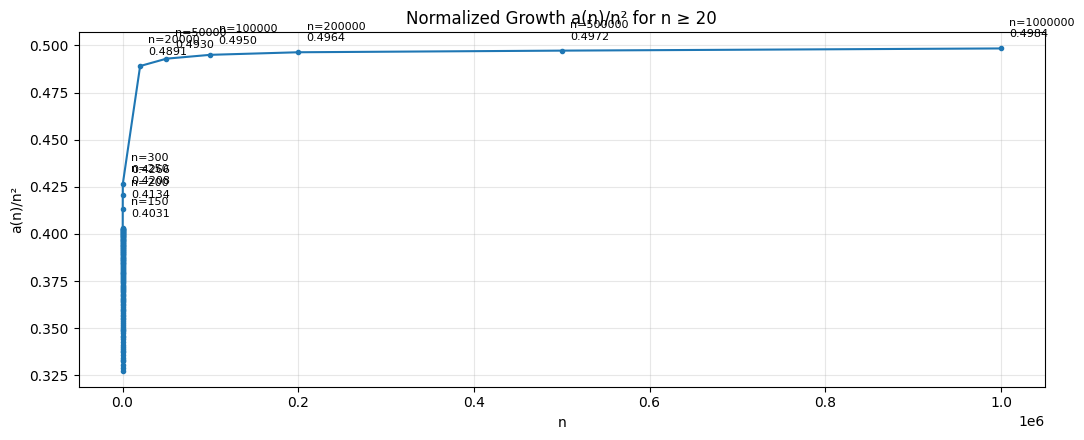

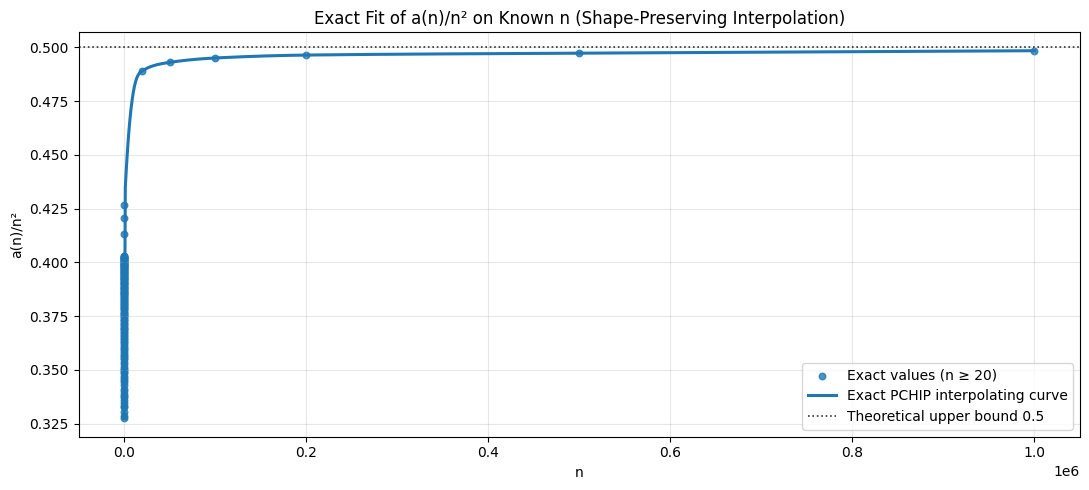

Exact interpolation diagnostics:
  Number of fitted points: 140
  Max |model(n)-observed| on known points: 0.000e+00
  The curve passes through all known points exactly, including n=150, 200, and 300.


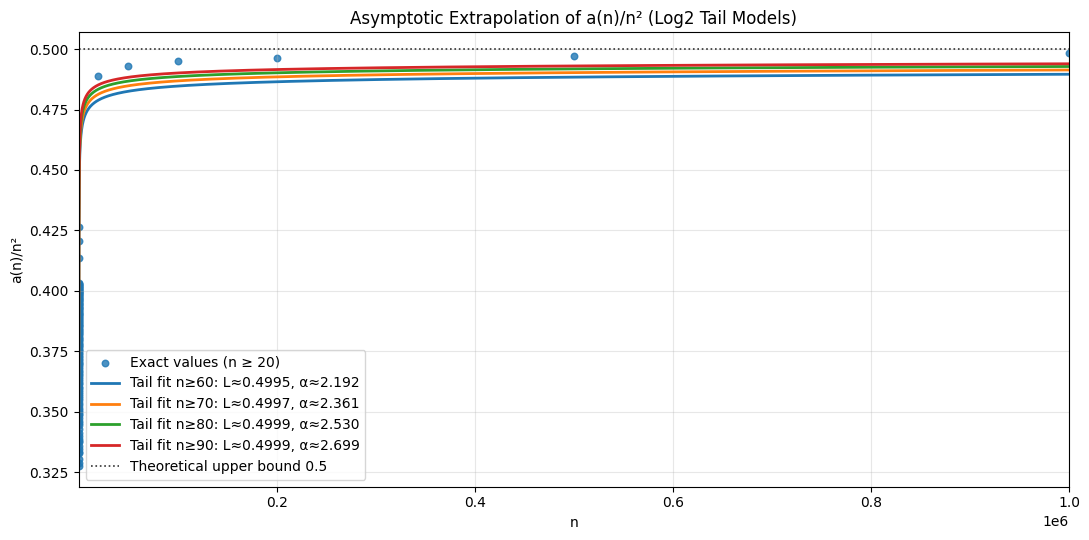


Asymptotic estimate from log2-tail models:
  cutoff n>=60: L ≈ 0.499540, alpha ≈ 2.192237, RMSE ≈ 4.616594e-03
  cutoff n>=70: L ≈ 0.499744, alpha ≈ 2.361187, RMSE ≈ 4.280958e-03
  cutoff n>=80: L ≈ 0.499876, alpha ≈ 2.530137, RMSE ≈ 3.973626e-03
  cutoff n>=90: L ≈ 0.499906, alpha ≈ 2.699087, RMSE ≈ 3.690473e-03

Recommended current asymptotic constant: L ≈ 0.499810
Stability range across tail cutoffs: [0.499540, 0.499906]
(All fits constrained by theoretical bound L < 0.5.)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Exact cached values, filtered to n >= 20
n_all = np.array([r["n"] for r in all_results], dtype=float)
a_all = np.array([r["a(n)"] for r in all_results], dtype=float)
ratio_all = a_all / (n_all ** 2)

mask = n_all >= 20
n_20 = n_all[mask]
ratio_20 = ratio_all[mask]

# Additional exact large-n values supplied by user
extra_exact = {
    150: 9070,
    200: 16535,
    250: 26301,
    300: 38393,
    20000: 195626217,
    50000: 1232434031,
    100000: 4950119352,
    200000: 19854820748,
    500000: 124309103223,
    1000000: 498395037477
}

# Merge exact datasets (override if n already exists)
ratio_by_n = {int(n): float(r) for n, r in zip(n_20, ratio_20)}
for n, an in extra_exact.items():
    ratio_by_n[int(n)] = float(an) / (n ** 2)

n_ext = np.array(sorted(ratio_by_n.keys()), dtype=float)
ratio_ext = np.array([ratio_by_n[int(n)] for n in n_ext], dtype=float)

# --- Chart 1: normalized values for n >= 20 including added exact points ---
plt.figure(figsize=(11, 4.5))
plt.plot(n_ext, ratio_ext, marker="o", linewidth=1.5, markersize=3)

for n in sorted(extra_exact.keys()):
    y = ratio_by_n[n]
    plt.annotate(f"n={n}\n{y:.4f}", (n, y), textcoords="offset points", xytext=(6, 8), fontsize=8)

plt.title("Normalized Growth a(n)/n² for n ≥ 20")
plt.xlabel("n")
plt.ylabel("a(n)/n²")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 2: exact fit on observed range via shape-preserving interpolation ---
interp_model = PchipInterpolator(n_ext, ratio_ext)

n_plot_obs = np.linspace(n_ext.min(), n_ext.max(), 800)
y_interp_obs = interp_model(n_plot_obs)

plt.figure(figsize=(11, 5))
plt.scatter(n_ext, ratio_ext, s=22, alpha=0.8, label="Exact values (n ≥ 20)")
plt.plot(n_plot_obs, y_interp_obs, linewidth=2.2, label="Exact PCHIP interpolating curve")
plt.axhline(0.5, color="black", linewidth=1.2, alpha=0.8, linestyle=":", label="Theoretical upper bound 0.5")

plt.title("Exact Fit of a(n)/n² on Known n (Shape-Preserving Interpolation)")
plt.xlabel("n")
plt.ylabel("a(n)/n²")
plt.grid(alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Exactness check
interp_at_points = interp_model(n_ext)
max_abs_error = np.max(np.abs(interp_at_points - ratio_ext))

print("Exact interpolation diagnostics:")
print(f"  Number of fitted points: {len(n_ext)}")
print(f"  Max |model(n)-observed| on known points: {max_abs_error:.3e}")
print("  The curve passes through all known points exactly, including n=150, 200, and 300.")

# --- Chart 3: asymptotic extrapolation beyond observed range ---
# Tail model: y(n) = L - c/(log2 n)^alpha, with constraints L < 0.5, c >= 0

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def fit_log2_tail_model(n_vals, y_vals, alpha_grid, L_upper=0.499999):
    best = None
    logn = np.log2(n_vals)

    for alpha in alpha_grid:
        x = 1.0 / (logn ** alpha)
        # Linear least squares for y = L - c*x => y = b0 + b1*x with L=b0, c=-b1
        A = np.column_stack([np.ones_like(x), x])
        b0, b1 = np.linalg.lstsq(A, y_vals, rcond=None)[0]

        L = float(b0)
        c = float(-b1)
        if (L >= L_upper) or (c < 0.0):
            continue

        y_hat = L - c * x
        err = rmse(y_vals, y_hat)

        if (best is None) or (err < best["rmse"]):
            best = {
                "L": L,
                "c": c,
                "alpha": float(alpha),
                "rmse": float(err),
            }

    if best is None:
        raise RuntimeError("No feasible log2-tail fit found under constraints.")

    return best


def log2_tail_predict(n_vals, fit):
    return fit["L"] - fit["c"] / (np.log2(n_vals) ** fit["alpha"])


alpha_grid = np.linspace(0.3, 4.0, 220)
tail_cutoffs = [60, 70, 80, 90]

tail_fits = {}
for cutoff in tail_cutoffs:
    tail_mask = n_ext >= cutoff
    n_tail = n_ext[tail_mask]
    y_tail = ratio_ext[tail_mask]
    tail_fits[cutoff] = fit_log2_tail_model(n_tail, y_tail, alpha_grid)

# Build extrapolation plot range
n_plot_ext = np.linspace(60, 1000000, 100000)

plt.figure(figsize=(11, 5.5))
plt.scatter(n_ext, ratio_ext, s=22, alpha=0.8, label="Exact values (n ≥ 20)")

for cutoff in tail_cutoffs:
    fit = tail_fits[cutoff]
    y_curve = log2_tail_predict(n_plot_ext, fit)
    plt.plot(
        n_plot_ext,
        y_curve,
        linewidth=2,
        label=f"Tail fit n≥{cutoff}: L≈{fit['L']:.4f}, α≈{fit['alpha']:.3f}",
    )

plt.axhline(0.5, color="black", linewidth=1.2, alpha=0.8, linestyle=":", label="Theoretical upper bound 0.5")
plt.xlim(20, 1000000)
plt.title("Asymptotic Extrapolation of a(n)/n² (Log2 Tail Models)")
plt.xlabel("n")
plt.ylabel("a(n)/n²")
plt.grid(alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Robust asymptotic summary from multiple tail cutoffs
L_values = np.array([tail_fits[c]["L"] for c in tail_cutoffs], dtype=float)
alpha_values = np.array([tail_fits[c]["alpha"] for c in tail_cutoffs], dtype=float)

L_median = float(np.median(L_values))
L_min = float(np.min(L_values))
L_max = float(np.max(L_values))

print("\nAsymptotic estimate from log2-tail models:")
for cutoff in tail_cutoffs:
    fit = tail_fits[cutoff]
    print(
        f"  cutoff n>={cutoff}: L ≈ {fit['L']:.6f}, alpha ≈ {fit['alpha']:.6f}, RMSE ≈ {fit['rmse']:.6e}"
    )

print(f"\nRecommended current asymptotic constant: L ≈ {L_median:.6f}")
print(f"Stability range across tail cutoffs: [{L_min:.6f}, {L_max:.6f}]")
print("(All fits constrained by theoretical bound L < 0.5.)")

## De Bruijn Embedding Analysis

For each $n$, we find the minimum de Bruijn order $k$ such that an optimal $n$-bit string can be embedded as a contiguous substring of a linear de Bruijn sequence $B(2,k)$ of length $2^k + k - 1$.

- **best $k$**: the smallest $k$ achievable by any optimal string for that $n$
- **worst $k$**: the largest $k$ needed across all optimal strings for that $n$
- **$\Delta\Delta a$**: second difference of $a(n)$, included because the jumps in $k$ align with the non-constant second differences

The chart below shows best $k$ and worst $k$ vs $n$, revealing the staircase growth pattern.

In [ ]:
import json, os
from IPython.display import display, HTML

db_path = os.path.join(PROJECT_ROOT, "results", "debruijn_analysis.json")

with open(db_path) as f:
    db_data = json.load(f)

# Compute ΔΔa from all_results (defined in earlier cell)
dda_by_n = {}
for i, r in enumerate(all_results):
    if i >= 2:
        d1 = all_results[i]["a(n)"] - all_results[i-1]["a(n)"]
        d0 = all_results[i-1]["a(n)"] - all_results[i-2]["a(n)"]
        dda_by_n[r["n"]] = d1 - d0

# Build tabbed groups of 10
max_n_db = max(r["n"] for r in db_data)
groups_db = []
for start in range(1, max_n_db + 1, 10):
    end = min(start + 9, max_n_db)
    if any(start <= r["n"] <= end for r in db_data):
        groups_db.append((start, end))

db_by_n = {r["n"]: r for r in db_data}

buttons_html_db = ""
tables_html_db = ""

for i, (start, end) in enumerate(groups_db):
    group_id = f"db_group_{start}_{end}"
    active = "active-db" if i == 0 else ""
    display_style = "block" if i == 0 else "none"

    buttons_html_db += f'<button class="db-btn {active}" onclick="showDbGroup(\'{group_id}\')">n={start}–{end}</button>\n'

    rows = ""
    for n in range(start, end + 1):
        if n not in db_by_n:
            continue
        r = db_by_n[n]
        k_range = r["worst_k"] - r["best_k"]
        dda = dda_by_n.get(n, None)
        dda_str = str(dda) if dda is not None else "–"
        rows += (
            f"<tr>"
            f"<td style='text-align:right; padding:3px 10px;'>{n}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['a_n']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['num_optimal']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['best_k']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['worst_k']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{k_range}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['best_debruijn_length']:,}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{dda_str}</td>"
            f"</tr>\n"
        )

    tables_html_db += f"""
<div id="{group_id}" class="db-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:right;">n</th>
  <th style="padding:4px 10px; text-align:right;">a(n)</th>
  <th style="padding:4px 10px; text-align:right;"># opt</th>
  <th style="padding:4px 10px; text-align:right;">best k</th>
  <th style="padding:4px 10px; text-align:right;">worst k</th>
  <th style="padding:4px 10px; text-align:right;">k range</th>
  <th style="padding:4px 10px; text-align:right;">best dB length</th>
  <th style="padding:4px 10px; text-align:right;">ΔΔa</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html_db = f"""
<style>
.db-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.db-btn:hover {{ background-color: #ddd; }}
.db-btn.active-db {{
    background-color: #00897B;
    color: white;
    border-bottom: 2px solid #00897B;
}}
.db-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showDbGroup(groupId) {{
    var tables = document.getElementsByClassName('db-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('db-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-db'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-db');
}}
</script>
<h3>De Bruijn Embedding: Minimum Order k by n</h3>
<p style="font-size:12px; color:#555;">
  For each n, best k = min over all optimal strings, worst k = max.
  A string embeds in B(2,k) iff all its k-substrings are distinct.
  ΔΔa is the second difference of a(n); k increments align with ΔΔa spikes.
</p>
<div style="margin-bottom: 10px;">{buttons_html_db}</div>
{tables_html_db}
"""
display(HTML(html_db))

n,a(n),# opt,best k,worst k,k range,best dB length,ΔΔa
1,1,2,1,1,0,2,–
2,3,1,1,1,0,2,–
3,5,1,2,2,0,5,0
4,7,3,2,3,1,5,0
5,10,2,3,3,0,10,1
6,13,6,3,4,1,10,0
7,17,5,3,4,1,10,1
8,22,1,4,4,0,19,1
9,27,4,4,5,1,19,0
10,33,5,4,5,1,19,1


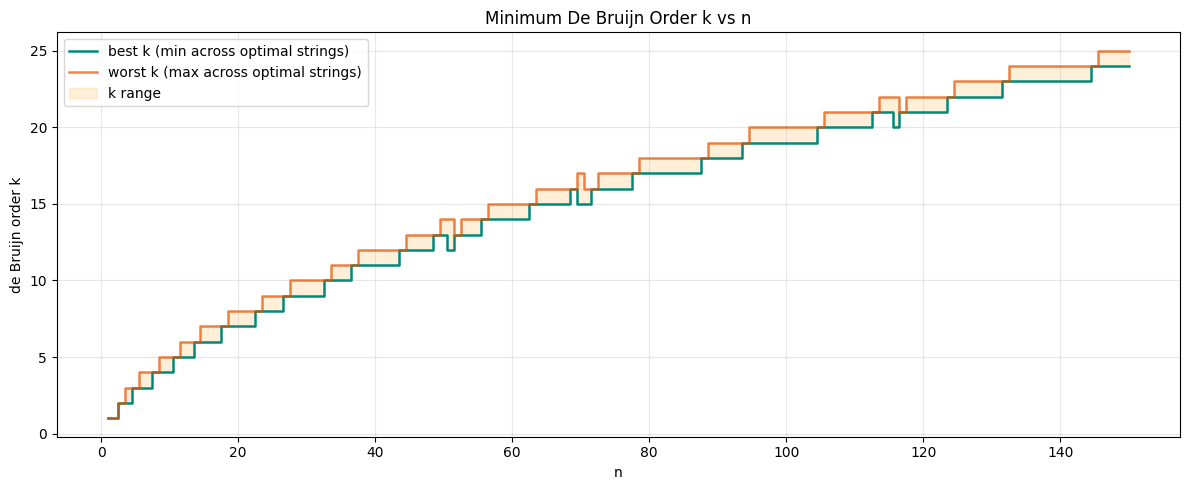

Values of n analysed: 150
  k range = 0 (all optimal strings agree): 28
  k range = 1: 119
  k range ≥ 2: 3  (n = [51, 70, 116])


In [11]:
import matplotlib.pyplot as plt

n_db = [r["n"] for r in db_data]
best_k = [r["best_k"] for r in db_data]
worst_k = [r["worst_k"] for r in db_data]

fig, ax = plt.subplots(figsize=(12, 5))

ax.step(n_db, best_k, where="mid", linewidth=1.8, color="#00897B", label="best k (min across optimal strings)")
ax.step(n_db, worst_k, where="mid", linewidth=1.8, color="#E65100", alpha=0.7, label="worst k (max across optimal strings)")
ax.fill_between(n_db, best_k, worst_k, alpha=0.15, color="#FF9800", step="mid", label="k range")

ax.set_xlabel("n")
ax.set_ylabel("de Bruijn order k")
ax.set_title("Minimum De Bruijn Order k vs n")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
same = sum(1 for b, w in zip(best_k, worst_k) if b == w)
diff1 = sum(1 for b, w in zip(best_k, worst_k) if w - b == 1)
diff2 = sum(1 for b, w in zip(best_k, worst_k) if w - b >= 2)
print(f"Values of n analysed: {len(n_db)}")
print(f"  k range = 0 (all optimal strings agree): {same}")
print(f"  k range = 1: {diff1}")
print(f"  k range ≥ 2: {diff2}  (n = {[n for n, b, w in zip(n_db, best_k, worst_k) if w - b >= 2]})")

### Worked Example: $n = 14$, $k = 6$

The 4 optimal strings for $n=14$ all have $a(14)=64$ and all require minimum de Bruijn order $k=6$.
The linear de Bruijn sequence $B(2,6)$ has length $2^6 + 5 = 69$ and contains every 6-bit binary string exactly once.

Below we construct, for each optimal string, a $B(2,6)$ that contains it as a contiguous substring, and highlight its position. (Since each 6-gram appears exactly once in any $B(2,6)$, different optimal strings generally require different de Bruijn sequences.)

In [12]:
from collections import defaultdict
from IPython.display import display, HTML

def build_db_containing(s, k):
    """Construct a linear de Bruijn sequence B(2,k) containing s as a substring."""
    used_edges = [s[i:i+k] for i in range(len(s) - k + 1)]
    used_set = set(used_edges)
    all_edges = [format(i, f'0{k}b') for i in range(2**k)]
    remaining = [e for e in all_edges if e not in used_set]

    adj = defaultdict(list)
    for e in remaining:
        adj[e[:k-1]].append(e[1:])
    for u in adj:
        adj[u].sort()

    end_node = s[-(k-1):]
    stack = [end_node]
    path = []
    local_adj = defaultdict(list)
    for u in adj:
        local_adj[u] = list(adj[u])
    while stack:
        v = stack[-1]
        if local_adj[v]:
            stack.append(local_adj[v].pop(0))
        else:
            path.append(stack.pop())
    path.reverse()

    prefix = path[0] + ''.join(node[-1] for node in path[1:]) if path else end_node
    return prefix + s[k-1:]

# n=14 optimal strings (all with min_k = 6)
n_example = 14
k_example = 6
opt_strings = cache["14"]["optimal_strings"]
db_len = 2**k_example + k_example - 1

rows_html = ""
for s in opt_strings:
    db = build_db_containing(s, k_example)
    idx = db.find(s)
    # Verify valid de Bruijn sequence
    distinct = len(set(db[i:i+k_example] for i in range(len(db) - k_example + 1)))
    assert distinct == 2**k_example, f"Bad dB sequence: {distinct} distinct {k_example}-substrings"
    assert idx >= 0, f"String {s} not found in constructed B(2,{k_example})"

    # Build highlighted string: before [MATCH] after
    before = db[:idx]
    match = db[idx:idx+len(s)]
    after = db[idx+len(s):]
    highlighted = (
        f"<span style='color:#888;'>{before}</span>"
        f"<span style='background:#FFEB3B; color:#000; font-weight:bold; padding:1px 2px; border-radius:2px;'>{match}</span>"
        f"<span style='color:#888;'>{after}</span>"
    )

    rows_html += (
        f"<tr>"
        f"<td style='padding:6px 10px; font-family:monospace; font-size:13px;'>{s}</td>"
        f"<td style='padding:6px 10px; text-align:right;'>{idx}</td>"
        f"<td style='padding:6px 10px; font-family:monospace; font-size:11px; word-break:break-all;'>{highlighted}</td>"
        f"</tr>\n"
    )

html_example = f"""
<h4>n = {n_example}: all {len(opt_strings)} optimal strings embed in B(2,{k_example})</h4>
<p style="font-size:12px; color:#555;">
  B(2,{k_example}) has length 2<sup>{k_example}</sup> + {k_example} − 1 = {db_len} and contains all {2**k_example} binary {k_example}-grams exactly once.
  Each optimal string (length {n_example}) uses only {n_example - k_example + 1} of the {2**k_example} available {k_example}-grams.
  The <span style="background:#FFEB3B; padding:1px 4px; border-radius:2px;">highlighted</span> portion shows where the optimal string sits within its de Bruijn host.
</p>
<table style="border-collapse:collapse; font-size:13px; width:100%; margin-top:8px;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:left;">Optimal string</th>
  <th style="padding:4px 10px; text-align:right;">Position</th>
  <th style="padding:4px 10px; text-align:left;">B(2,{k_example}) with string highlighted</th>
</tr>
</thead>
<tbody>
{rows_html}
</tbody>
</table>
<p style="font-size:12px; color:#555; margin-top:8px;">
  Note: The 4 strings share the prefix <code>1111110111</code> and differ only in the last 4 bits.
  Since each {k_example}-gram appears exactly once in any B(2,{k_example}), different optimal strings
  generally require different de Bruijn host sequences.
</p>
"""
display(HTML(html_example))


Optimal string,Position,"B(2,6) with string highlighted"
11111101110000,55,100000010000110001010001110100100110101011011001011110011111101110000
11111101110001,55,100010000001010001100001110100100110101011011001011110011111101110001
11111101110010,55,100100000010010100010110000110011011010011101010111100011111101110010
11111101110011,55,100110000001000011010001010010011101010110110010111100011111101110011
